# Car Resale Price Prediction
## Course: BAN644

**Problem Type:** Regression — Predicting a continuous variable (Car Reselling Price)

**Dataset Source:** [Kaggle — Car Price Prediction Dataset]
(https://www.kaggle.com/datasets/jacksondivakarr/sample34/data)

---
### Project Outline
1. Data Collection
2. Data Preprocessing
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Model Building
6. Model Optimization
7. Model Evaluation & Validation
8. Business Insights & Recommendations

---
## 1. Data Collection

The dataset was downloaded from **Kaggle** ([link]https://www.kaggle.com/datasets/jacksondivakarr/sample34/data)). It contains **2,095 used car sale records** with **12 features** including structural, locational, and condition-based attributes, and the target variable `selling_price` (car resale price in Rupees).

| Feature | Description |
|---|---|
| name | Car brand |
|  year | The year the car was first purchased |
| km_driven | How many kilometers driven before reselling |
| fuel | Fuel type (Example: petrol,diesel etc.) |
| seller_type | Sold by an individual or an agency etc. |
| trasnmission | Gear type |
| owner | How many generations the car was owned for |
| seats | How many seats |
| mileage | Current mileage per litre of fuel |
| mileage unit | Unit of mileage |
| engine(cc) | Engine capacity |
| max_power (in bph) | Current break horse power of engine|
| selling price | **Target variable** — car resale price |

In [1]:
# ── Importing necessary libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [2]:
from google.colab import drive
import os

# Mount drive
drive.mount('/content/drive', force_remount=True)

# Define path and check if file exists to make it robust
file_path = '/content/drive/MyDrive/644 Project Dataset/Car Resale Price Prediction.csv'

if os.path.exists(file_path):
    car = pd.read_csv(file_path)
    housing_original = car.copy()
    print(f"✅ Dataset loaded. Shape: {car.shape}")
    display(car.head(10))
else:
    print(f"❌ File not found at {file_path}. Please check the path.")

Mounted at /content/drive
✅ Dataset loaded. Shape: (2095, 14)


,Unnamed: 0,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,seats,max_power (in bph),Mileage Unit,Mileage,Engine (CC)
0,0,Maruti,2014,450000,145500,Diesel,Individual,Manual,First Owner,5.0,74.00,kmpl,23.40,1248.0
1,2,Hyundai,2010,225000,127000,Diesel,Individual,Manual,First Owner,5.0,90.00,kmpl,23.00,1396.0
2,4,Hyundai,2017,440000,45000,Petrol,Individual,Manual,First Owner,5.0,81.86,kmpl,20.14,1197.0
3,7,Toyota,2011,350000,90000,Diesel,Individual,Manual,First Owner,5.0,67.10,kmpl,23.59,1364.0
4,8,Ford,2013,200000,169000,Diesel,Individual,Manual,First Owner,5.0,68.10,kmpl,20.00,1399.0
5,15,Hyundai,2012,500000,53000,Diesel,Individual,Manual,Second Owner,5.0,90.00,kmpl,23.00,NaN
6,16,Maruti,2002,150000,80000,Petrol,Individual,Manual,Second Owner,5.0,46.30,kmpl,19.70,796.0
7,17,Hyundai,2016,680000,100000,Diesel,Individual,Manual,First Owner,5.0,88.73,kmpl,22.54,1396.0
8,18,Mahindra,2011,174000,100000,Diesel,Individual,Manual,Second Owner,5.0,64.10,kmpl,21.00,1461.0
9,21,Maruti,2012,600000,72000,Diesel,Individual,Manual,First Owner,5.0,88.80,kmpl,21.50,1248.0


---
## 2. Data Preprocessing

Preprocessing ensures the data is clean and ready for modeling. Steps:
- Identify and handle **missing values**
- Check for **negative values** (invalid for house features)
- **Drop irrelevant columns**
- **Encode categorical variables** using One-Hot Encoding
- **Scale** numerical features using StandardScaler

In [3]:
# ── Step 2.1 : Inspect missing values ──────────────────────────────────────
print("=== Missing Values Per Column ===")
print(car.isnull().sum())
print(f"\nTotal missing values: {car.isnull().sum().sum()}")

=== Missing Values Per Column ===
Unnamed: 0              0
name                    0
year                    0
selling_price           0
km_driven               0
fuel                    0
seller_type             0
transmission            0
owner                 120
seats                  13
max_power (in bph)     70
Mileage Unit            0
Mileage                29
Engine (CC)           152
dtype: int64

Total missing values: 384


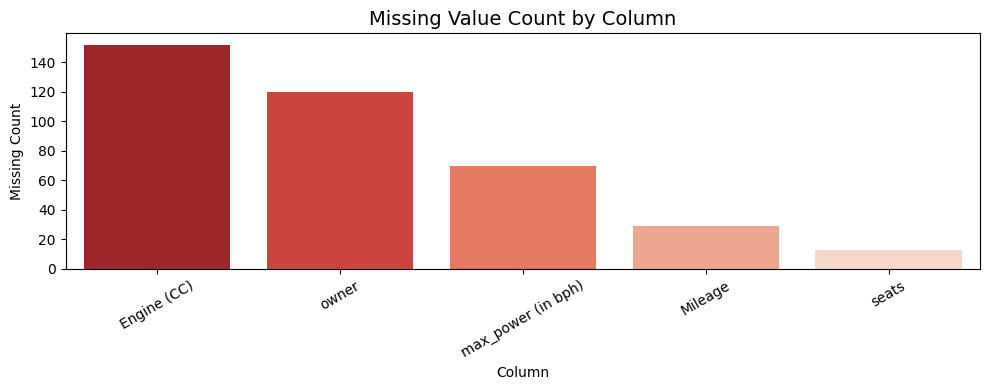

In [4]:
# ── Step 2.2 : Visualise missing values ────────────────────────────────────
missing = car.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
sns.barplot(x=missing.index, y=missing.values, palette='Reds_r')
plt.title('Missing Value Count by Column', fontsize=14)
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [5]:
# ── Step 2.3 : Drop irrelevant / high-missing columns ──────────────────────
car.drop(['Unnamed: 0','Mileage Unit'], axis=1, inplace=True)
print(f"Columns after dropping: {car.shape[1]}")
print(car.columns.tolist())

Columns after dropping: 12
['name', 'year', 'selling_price', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'seats', 'max_power (in bph)', 'Mileage', 'Engine (CC)']


In [ ]:
# ── Step 2.3b : Check and remove duplicate rows ────────────────────────────
duplicates = car.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

if duplicates > 0:
    car.drop_duplicates(inplace=True)
    print(f"✅ Duplicates removed. New shape: {car.shape}")
else:
    print("✅ No duplicate rows — dataset is clean.")

Duplicate rows found: 0
✅ No duplicate rows — dataset is clean.


In [6]:
# ── Step 2.4 : Impute missing values ───────────────────────────────────────
# Numerical columns → fill with MEAN (minimises distortion of distribution)
num_cols = ['year','km_driven','seats','max_power (in bph)','Mileage','Engine (CC)']

for col in num_cols:
    car[col] = car[col].fillna(car[col].mean())

# Categorical columns → fill with MODE (most frequent value)
cat_cols = ['name','fuel','seller_type','transmission','owner']

for col in cat_cols:
    car[col] = car[col].fillna(car[col].mode()[0])

print("=== Missing Values After Imputation ===")
print(car.isnull().sum())
print(f"\nTotal remaining missing values: {car.isnull().sum().sum()}")

=== Missing Values After Imputation ===
name                  0
year                  0
selling_price         0
km_driven             0
fuel                  0
seller_type           0
transmission          0
owner                 0
seats                 0
max_power (in bph)    0
Mileage               0
Engine (CC)           0
dtype: int64

Total remaining missing values: 0


In [ ]:
# ── Step 2.5 : Check for invalid negative values ───────────────────────────
print("=== Negative Value Check ===")
for col in num_cols + ['selling_price']:
    has_neg = (car[col] < 0).any()
    status = "⚠️  HAS negative values" if has_neg else "✅ No negative values"
    print(f"  {col:20s} → {status}")

=== Negative Value Check ===
  year                 → ✅ No negative values
  km_driven            → ✅ No negative values
  seats                → ✅ No negative values
  max_power (in bph)   → ✅ No negative values
  Mileage              → ✅ No negative values
  Engine (CC)          → ✅ No negative values
  selling_price        → ✅ No negative values


In [7]:
# ── Step 2.6 : Outlier detection & capping (IQR method) ───────────────────
print("=== Outlier Detection & Capping (IQR Method) ===")
for col in num_cols + ['selling_price']:
    Q1 = car[col].quantile(0.25)
    Q3 = car[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    before = ((car[col] < lower) | (car[col] > upper)).sum()
    car[col] = car[col].clip(lower=lower, upper=upper)
    after = ((car[col] < lower) | (car[col] > upper)).sum()
    print(f"  {col:20s} → {before} outliers found, capped to [{lower:.1f}, {upper:.1f}]  ✅")

print(f"\nTotal rows after capping: {car.shape[0]}  (no rows dropped)")

=== Outlier Detection & Capping (IQR Method) ===
  year                 → 17 outliers found, capped to [2004.5, 2024.5]  ✅
  km_driven            → 44 outliers found, capped to [-47500.0, 172500.0]  ✅
  seats                → 111 outliers found, capped to [5.0, 5.0]  ✅
  max_power (in bph)   → 116 outliers found, capped to [34.5, 121.3]  ✅
  Mileage              → 0 outliers found, capped to [17.2, 25.8]  ✅
  Engine (CC)          → 0 outliers found, capped to [403.5, 1991.5]  ✅
  selling_price        → 44 outliers found, capped to [-208250.0, 1013750.0]  ✅

Total rows after capping: 2095  (no rows dropped)


In [8]:
# ── Step 2.7 : One-Hot Encoding for categorical features ───────────────────
# Each unique category value becomes a binary (0/1) column.
car_encoded = pd.get_dummies(car, columns=cat_cols, dtype=int)

print(f"Shape before encoding : {car.shape}")
print(f"Shape after encoding  : {car_encoded.shape}")
car_encoded.head(3)

Shape before encoding : (2095, 12)
Shape after encoding  : (2095, 31)


,year,selling_price,km_driven,seats,max_power (in bph),Mileage,Engine (CC),name_Chevrolet,name_Ford,name_Honda,...,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Automatic,transmission_Manual,owner_First Owner,owner_Fourth & Above Owner,owner_Second Owner,owner_Test Drive Car,owner_Third Owner
0,2014.0,450000,145500,5.0,74.00,23.40,1248.0,0,0,0,...,0,1,0,0,1,1,0,0,0,0
1,2010.0,225000,127000,5.0,90.00,23.00,1396.0,0,0,0,...,0,1,0,0,1,1,0,0,0,0
2,2017.0,440000,45000,5.0,81.86,20.14,1197.0,0,0,0,...,0,1,0,0,1,1,0,0,0,0


# Train/test split

In [ ]:
X_raw = car_encoded.drop('selling_price', axis=1)
y     = car_encoded['selling_price'].values

# Split BEFORE any scaling
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.3, random_state=42)

Scale only on training data

In [ ]:
# Fit scaler on training data only, then transform both sets
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
X_test  = scaler.transform(X_test_raw)        # transform only on test

X_scaled = scaler.transform(X_raw)
X        = X_scaled

print(f"✅ Split-then-scale complete. Scaler fitted on training data only.")
print(f"   X_train shape : {X_train.shape}")
print(f"   X_test  shape : {X_test.shape}")
print(f"   y_train shape : {y_train.shape}")
print(f"   y_test  shape : {y_test.shape}")

✅ Split-then-scale complete. Scaler fitted on training data only.
   X_train shape : (1466, 30)
   X_test  shape : (629, 30)
   y_train shape : (1466,)
   y_test  shape : (629,)


---
## 3. Exploratory Data Analysis (EDA)

EDA helps us understand the data distribution, relationships between variables, and patterns that may influence the target variable (`selling_price`).

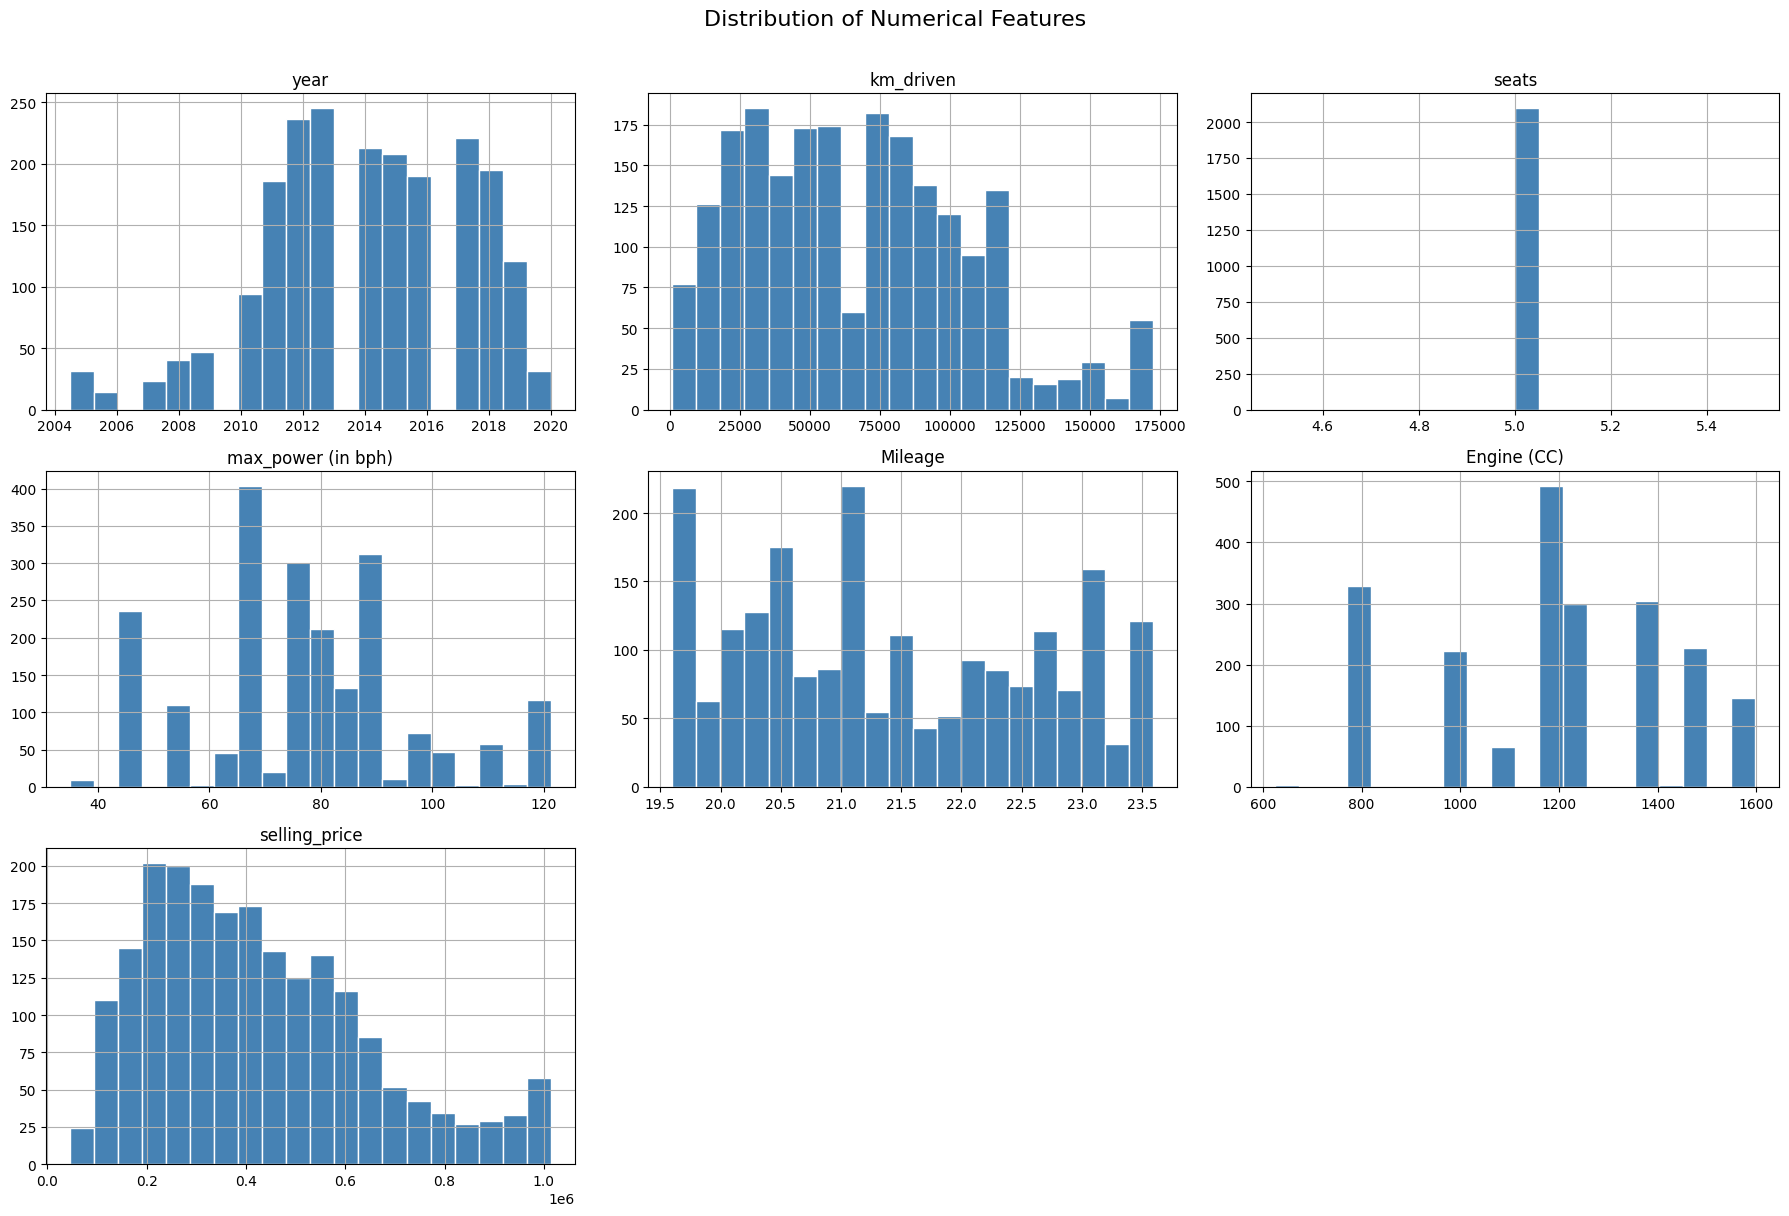

In [ ]:
# ── EDA 3.1 : Distribution of numerical features ───────────────────────────
car[num_cols + ['selling_price']].hist(bins=20, figsize=(18, 12), color='steelblue', edgecolor='white')
plt.suptitle('Distribution of Numerical Features', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

##Insight:
 Most numerical features show skewness, especially Resale Price. After log transformation, the distribution becomes more normal, which is suitable for regression models. bold text

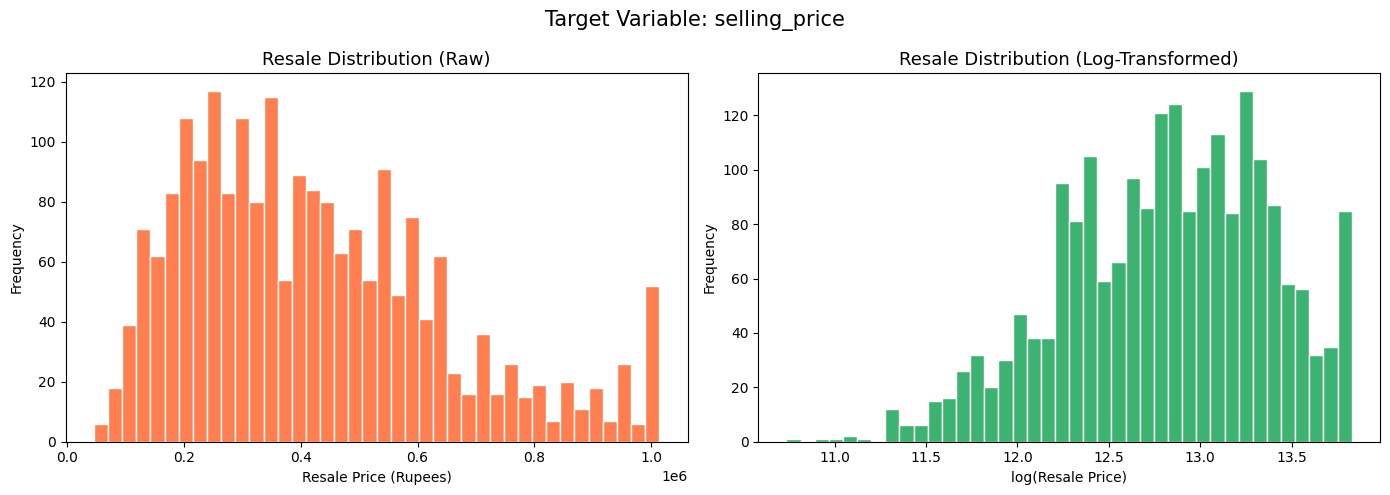

SalePrice — Mean: 424,225  |  Median: 390,000  |  Std: 223,287


In [10]:
# ── EDA 3.2 : Target variable (Resale Price) distribution ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution
axes[0].hist(car['selling_price'], bins=40, color='coral', edgecolor='white')
axes[0].set_title('Resale Distribution (Raw)', fontsize=13)
axes[0].set_xlabel('Resale Price (Rupees)')
axes[0].set_ylabel('Frequency')

# Log-transformed distribution
axes[1].hist(np.log1p(car['selling_price']), bins=40, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Resale Distribution (Log-Transformed)', fontsize=13)
axes[1].set_xlabel('log(Resale Price)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Target Variable: selling_price', fontsize=15)
plt.tight_layout()
plt.show()

print(f"SalePrice — Mean: {car['selling_price'].mean():,.0f}  |  Median: {car['selling_price'].median():,.0f}  |  Std: {car['selling_price'].std():,.0f}")

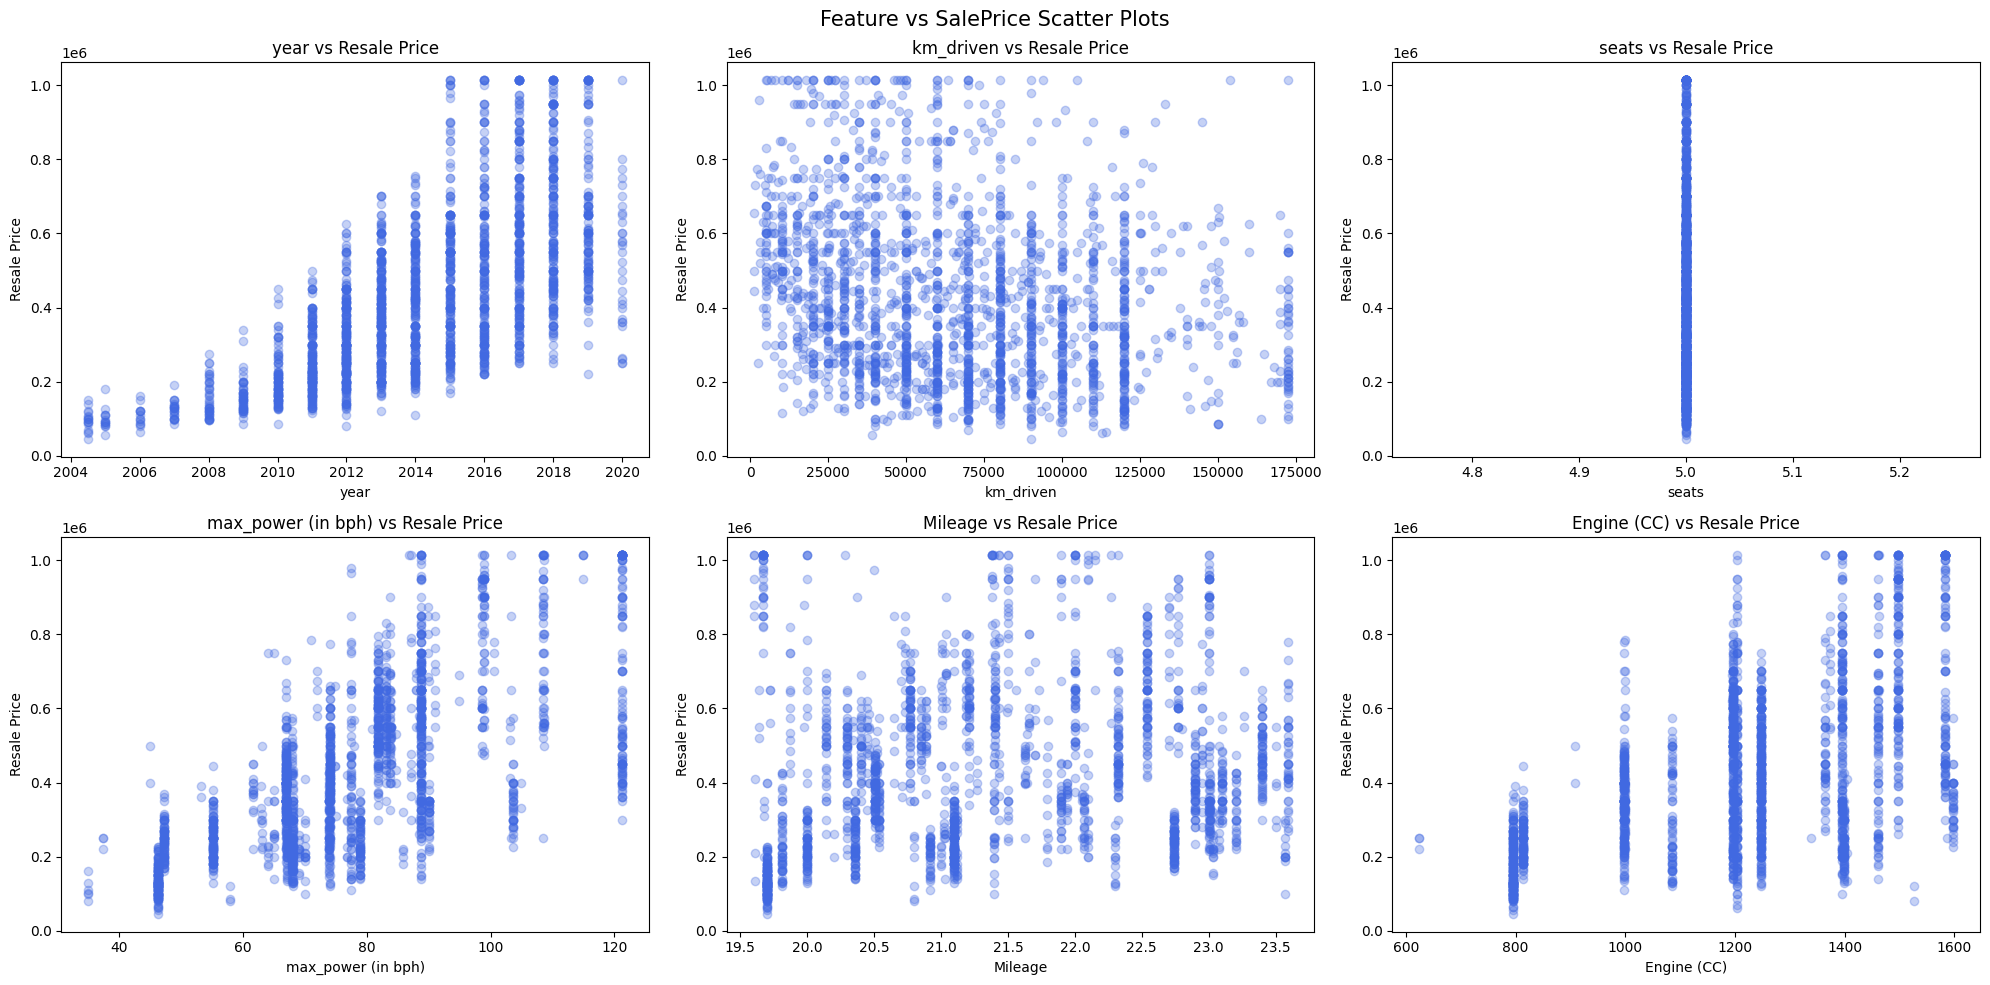

In [ ]:
# ── EDA 3.3 : Scatter plots — numerical features vs Resale Price ──────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].scatter(car[col], car['selling_price'], alpha=0.3, color='royalblue')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Resale Price')
    axes[i].set_title(f'{col} vs Resale Price')

plt.suptitle('Feature vs SalePrice Scatter Plots', fontsize=15)
plt.tight_layout()
plt.show()

# Insight:
selling_price distribution is right-skewed, indicating presence of high-value outliers.
After log transformation, the distribution becomes more normal, which is better for regression models.
# Weakness:
Seats shows little variation and weak relationship with selling_price,
indicating it may not be a strong predictor.

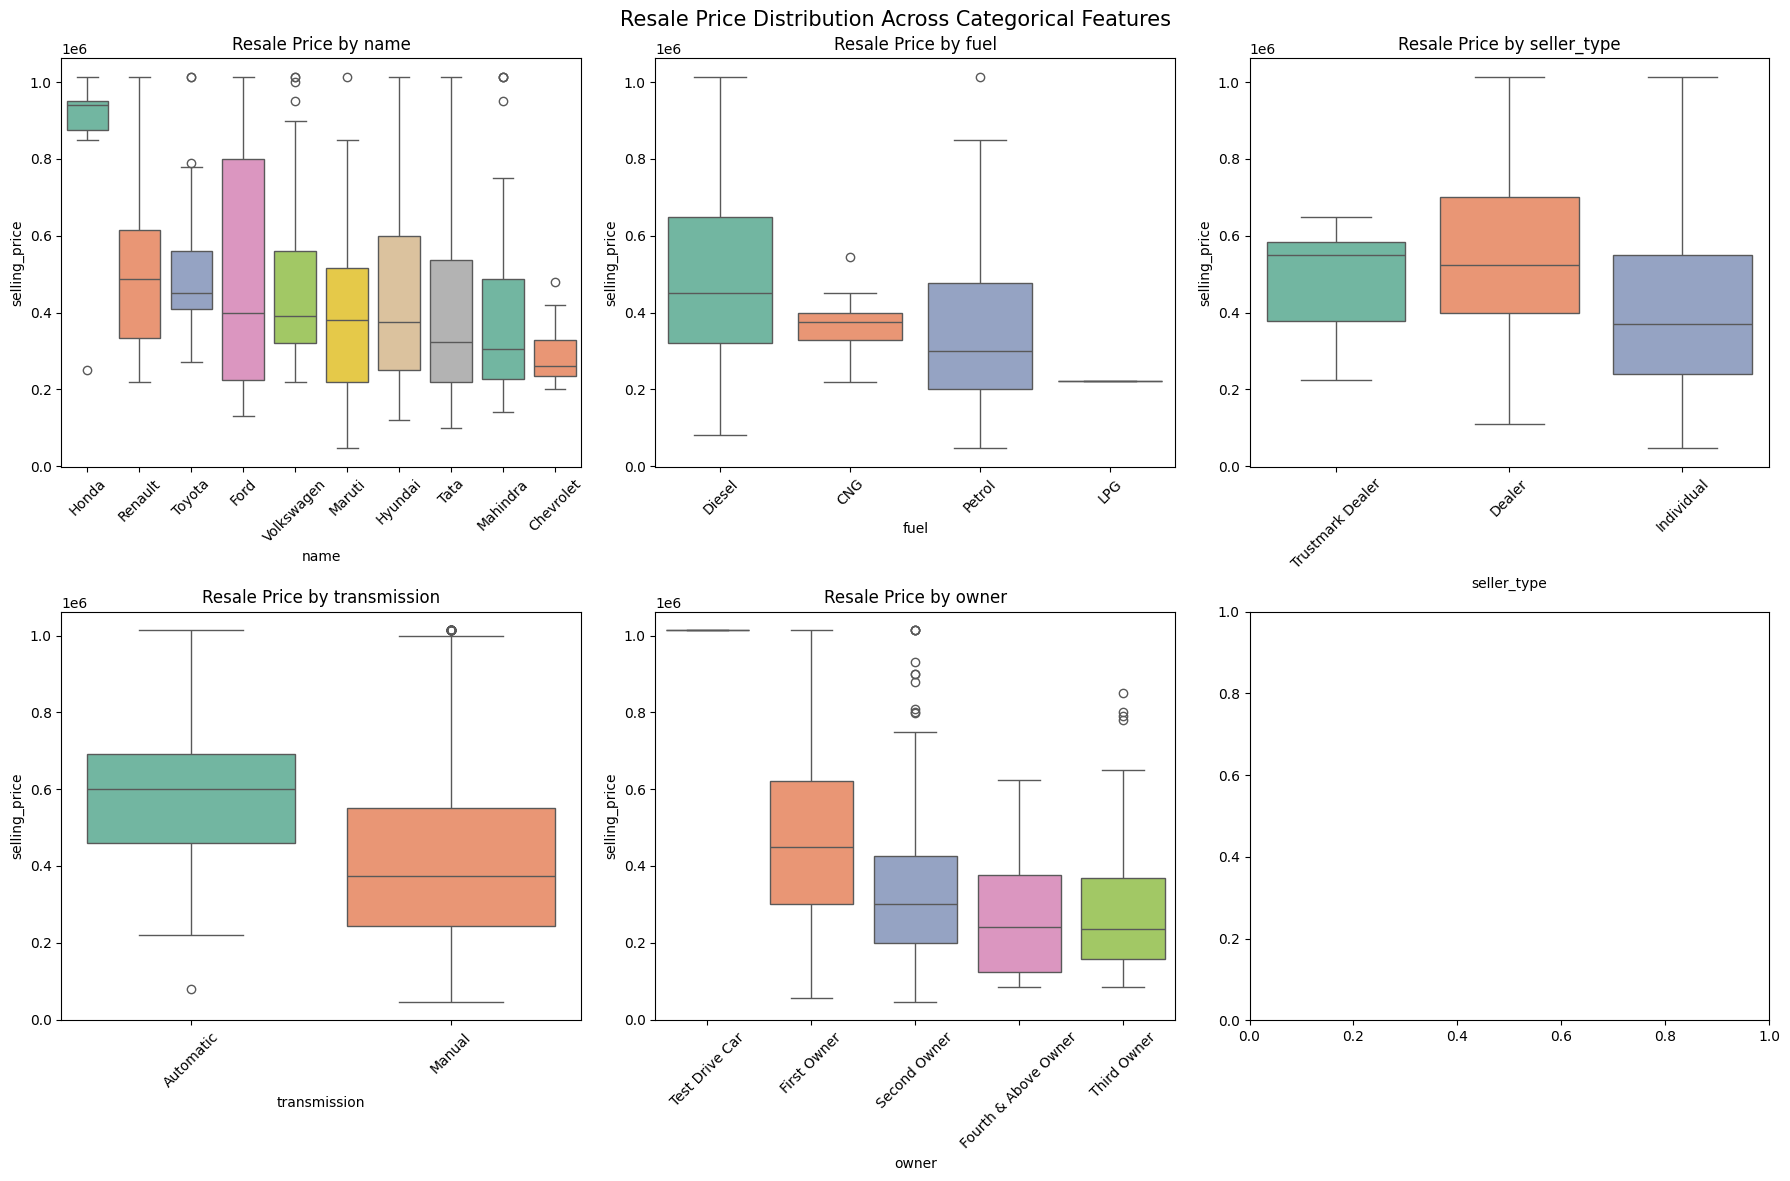

In [ ]:
# ── EDA 3.4 : Boxplots — Resale Price by categorical features ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

for ax, col in zip(axes.flatten(), ['name','fuel','seller_type','transmission','owner']):
    order = car.groupby(col)['selling_price'].median().sort_values(ascending=False).index
    sns.boxplot(data=car, x=col, y='selling_price', order=order, ax=ax, palette='Set2')
    ax.set_title(f'Resale Price by {col}', fontsize=12)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Resale Price Distribution Across Categorical Features', fontsize=15)
plt.tight_layout()
plt.show()

# Insight:
Neighborhood has a strong impact on SalePrice, with certain areas having consistently higher median prices.
This indicates location is a key factor in house pricing.

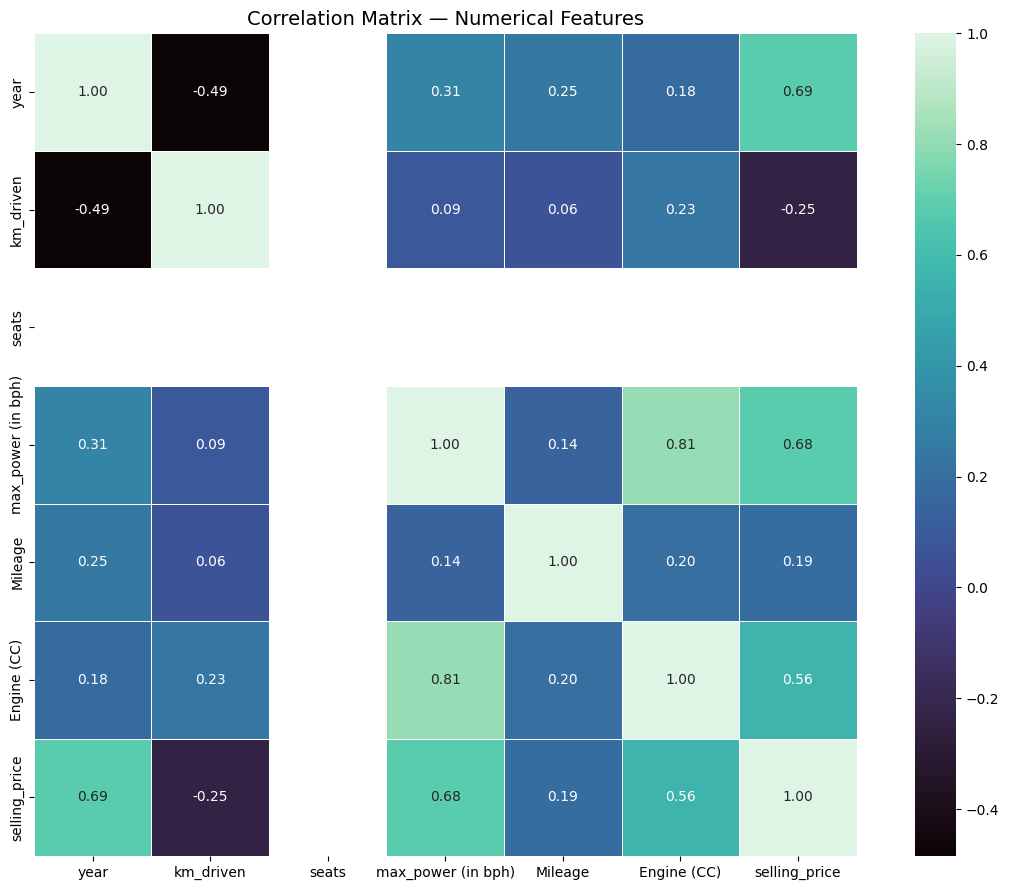

In [ ]:
# ── EDA 3.5 : Correlation heatmap (numerical features) ─────────────────────
numeric_cols = car[num_cols + ['selling_price']]

plt.figure(figsize=(12, 9))
sns.heatmap(numeric_cols.corr(), annot=True, fmt='.2f', cmap='mako',
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

# Insight:
GrLivArea has the highest correlation with SalePrice among numerical features,
making it one of the most important predictors.

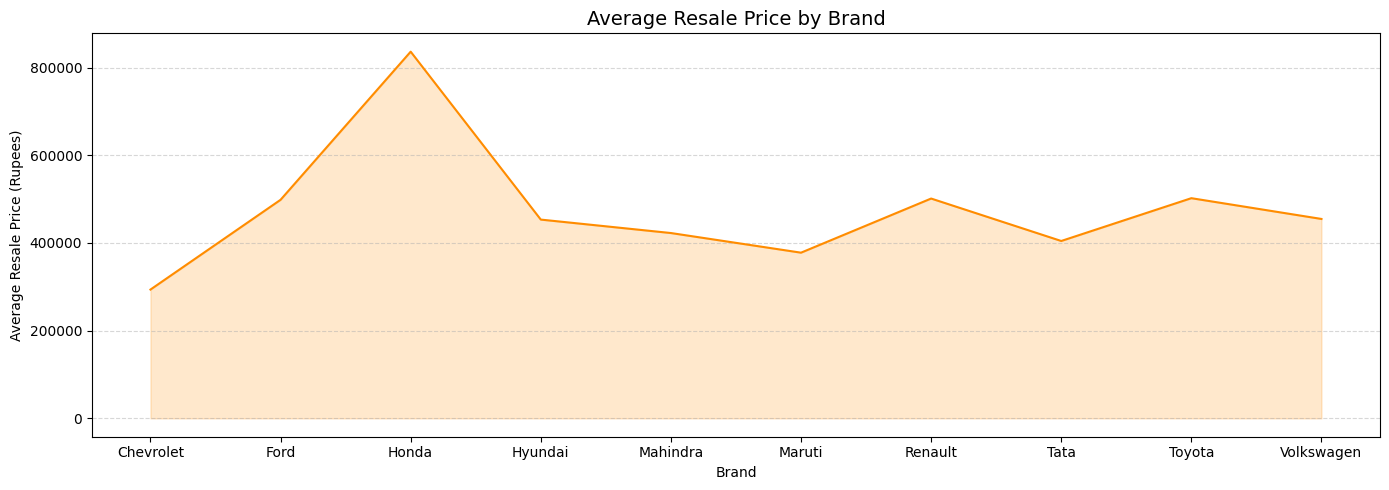

In [ ]:
# ── EDA 3.6 : Brand trend — average Resale Price over time ───────────────
year_price = car.groupby('name')['selling_price'].mean()

plt.figure(figsize=(14, 5))
plt.plot(year_price.index, year_price.values, color='darkorange', linewidth=1.5)
plt.fill_between(year_price.index, year_price.values, alpha=0.2, color='darkorange')
plt.title('Average Resale Price by Brand', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Average Resale Price (Rupees)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Insight:
Newer houses tend to have higher SalePrice, suggesting that construction year positively affects property value.

## 4. Feature Selection

Feature selection identifies which variables most strongly predict `SalePrice`, reducing noise and improving model performance. We use two approaches:
1. **Pearson Correlation** — measures linear relationship between each feature and the target
2. **Random Forest Feature Importance** — captures non-linear relationships as well

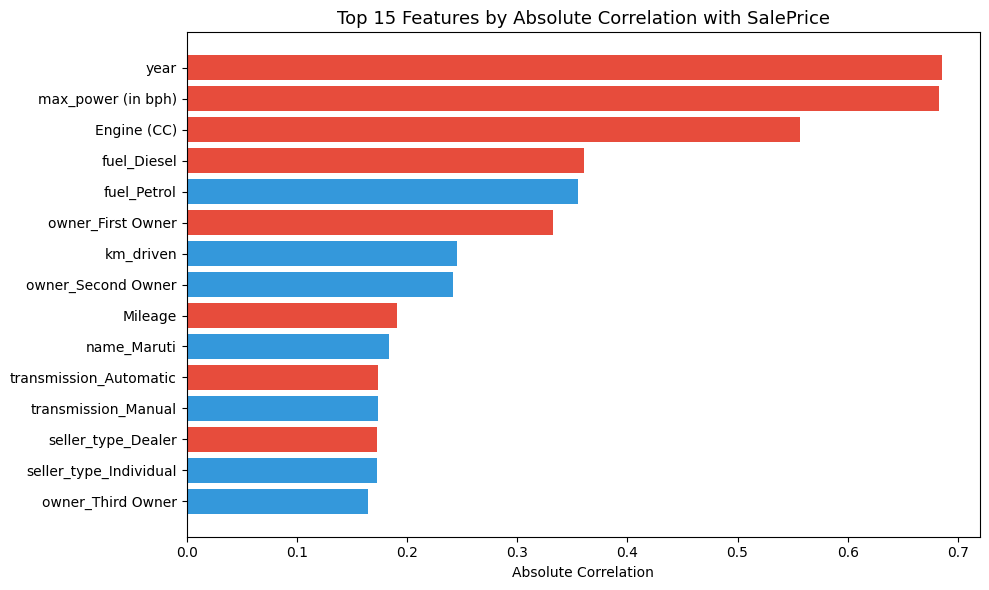

In [ ]:
# ── Feature Selection 4.1 : Pearson Correlation with SalePrice ─────────────
X_df = X_raw.copy()
corr_with_target = X_df.corrwith(pd.Series(y))

top_corr = corr_with_target.abs().sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_target[top_corr.index]]
plt.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
plt.title('Top 15 Features by Absolute Correlation with SalePrice', fontsize=13)
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

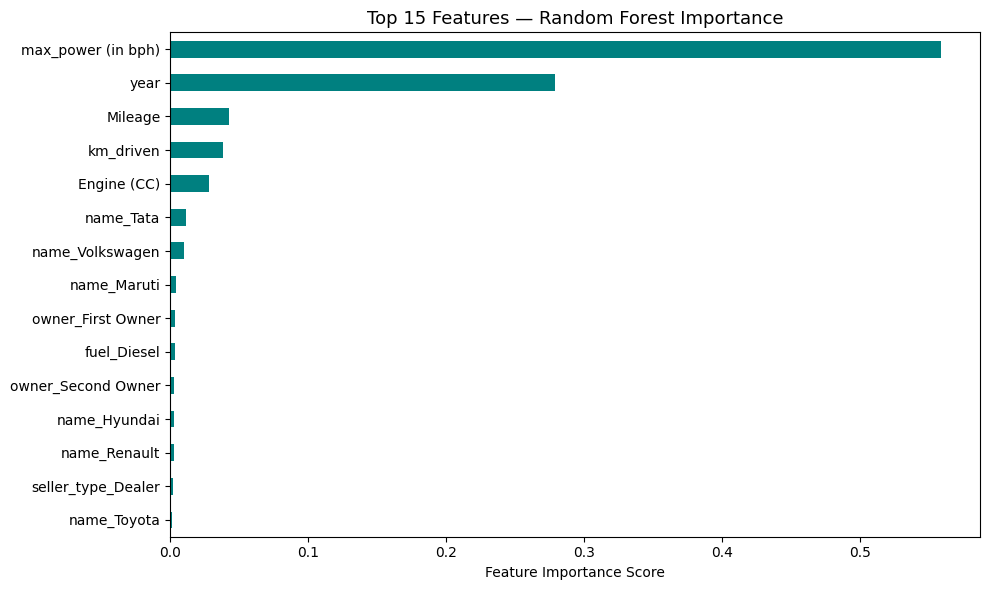


Top 10 important features (Random Forest):
max_power (in bph)    0.5588
year                  0.2790
Mileage               0.0428
km_driven             0.0380
Engine (CC)           0.0280
name_Tata             0.0116
name_Volkswagen       0.0099
name_Maruti           0.0042
owner_First Owner     0.0036
fuel_Diesel           0.0035
dtype: float64


In [ ]:
# ── Feature Selection 4.2 : Random Forest Feature Importance ───────────────
X = X_scaled
y = car_encoded['selling_price'].values

rf_selector = RandomForestRegressor(n_estimators=100, random_state=42)
rf_selector.fit(X, y)

importances = pd.Series(rf_selector.feature_importances_, index=X_raw.columns)  # ← X_raw.columns, not housing_encoded.columns
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
top_features[::-1].plot(kind='barh', color='teal')
plt.title('Top 15 Features — Random Forest Importance', fontsize=13)
plt.xlabel('Feature Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 10 important features (Random Forest):")
print(top_features.head(10).round(4))

In [ ]:
# ── Feature Selection 4.3 : Confirm split ───────────────
print("=== Train / Test Split (performed in Cell 2.8) ===")
print(f"  Total samples   : {len(X)}")
print(f"  Training samples: {len(X_train)}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Testing  samples: {len(X_test)}  ({len(X_test)/len(X)*100:.1f}%)")


overlap = set(X_train_raw.index) & set(X_test_raw.index)
print(f"\nTrain-Test overlap: {'⚠️ OVERLAP FOUND' if overlap else '✅ No overlap — split is clean'}")

=== Train / Test Split (performed in Cell 2.8) ===
  Total samples   : 2095
  Training samples: 1466  (70.0%)
  Testing  samples: 629  (30.0%)

Train-Test overlap: ✅ No overlap — split is clean


In [ ]:
# ── Feature Selection 4.4 : Final feature selection ───────────────────────

# Combine both methods (Correlation + Random Forest)
common_features = list(set(top_corr.index) & set(top_features.index))

print(f"Selected features ({len(common_features)}):")
print(common_features)

# Create reduced dataset USING selected features
X_selected = X_raw[common_features]

# Train-test split again using selected features
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.3, random_state=42
)

print("\n✅ Feature selection applied successfully")
print(f"New feature count: {X_selected.shape[1]}")

Selected features (10):
['owner_First Owner', 'fuel_Diesel', 'year', 'Mileage', 'seller_type_Dealer', 'km_driven', 'name_Maruti', 'Engine (CC)', 'owner_Second Owner', 'max_power (in bph)']

✅ Feature selection applied successfully
New feature count: 10


Both Pearson correlation and Random Forest importance were used to identify the most influential features.

The common features from both methods were selected to reduce dimensionality and improve model performance while minimizing noise and overfitting.

---
## 5. Model Building

We train **four regression models** and evaluate them before optimization:

| # | Model | Why chosen |
|---|---|---|
| 1 | Linear Regression | Simple baseline; interpretable coefficients |
| 2 | Decision Tree | Captures non-linear patterns; easy to visualise |
| 3 | Random Forest | Ensemble method; reduces overfitting from single trees |
| 4 | Support Vector Machine (SVM) | Effective in high-dimensional spaces |

> **Metrics used:** MAE, MAPE, MSE, RMSE, R²

In [ ]:
# Use selected features (NOT full dataset)
X = X_selected

In [ ]:
# ── Helper function : compute all regression metrics ───────────────────────
def evaluate_model(y_true, y_pred, model_name):
    mae  = mean_absolute_error(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_true, y_pred) * 100
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  MAE  : {mae:>15,.2f}")
    print(f"  MAPE : {mape:>14.2f} %")
    print(f"  MSE  : {mse:>15,.2f}")
    print(f"  RMSE : {rmse:>15,.2f}")
    print(f"  R²   : {r2:>14.4f} %")

    return {'Model': model_name, 'MAE': mae, 'MAPE': mape,
            'MSE': mse, 'RMSE': rmse, 'R2': r2}

results_before = []
print("✅ Helper function ready.")

✅ Helper function ready.



  Linear Regression
  MAE  :       80,867.09
  MAPE :          27.04 %
  MSE  : 11,010,862,438.06
  RMSE :      104,932.66
  R²   :        75.9264 %

  Train R²: 77.5384%
  Test  R²: 75.9264%


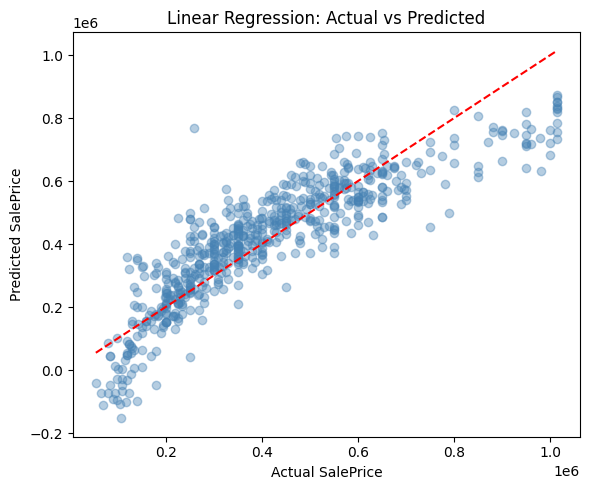

In [ ]:
# ── Model 5.1 : Linear Regression ──────────────────────────────────────────
linreg = LinearRegression()
linreg.fit(X_train, y_train)

residuals = y_train - linreg.predict(X_train)
mask_clean = np.abs(residuals) <= 3 * np.std(residuals)
linreg.fit(X_train[mask_clean], y_train[mask_clean])

y_pred_lr = linreg.predict(X_test)
res_lr = evaluate_model(y_test, y_pred_lr, 'Linear Regression')
results_before.append(res_lr)

print(f"\n  Train R²: {linreg.score(X_train[mask_clean], y_train[mask_clean])*100:.4f}%")
print(f"  Test  R²: {linreg.score(X_test, y_test)*100:.4f}%")

# Actual vs Predicted plot
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_lr, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Linear Regression: Actual vs Predicted')
plt.tight_layout()
plt.show()


  Decision Tree Regressor
  MAE  :       66,949.93
  MAPE :          19.39 %
  MSE  : 8,823,168,015.60
  RMSE :       93,931.72
  R²   :        80.7095 %

  Train R²: 99.6581%
  Test  R²: 80.7095%

  ⚠️  NOTE: An unconstrained Decision Tree achieves Train R² ≈ 100%
  because it creates a unique leaf for every training sample
  (memorization, not learning). Gap = 18.95%.
  This overfitting will be corrected in Section 6 via GridSearchCV.


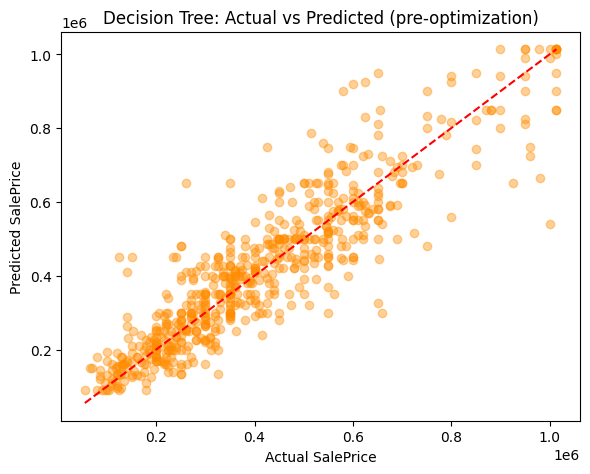

In [ ]:
# ── Model 5.2 : Decision Tree Regressor ────────────────────────────────────
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

res_dt = evaluate_model(y_test, y_pred_dt, 'Decision Tree Regressor')
results_before.append(res_dt)

train_r2 = dt.score(X_train, y_train) * 100
test_r2  = dt.score(X_test,  y_test)  * 100

print(f"\n  Train R²: {train_r2:.4f}%")
print(f"  Test  R²: {test_r2:.4f}%")
print(f"\n  ⚠️  NOTE: An unconstrained Decision Tree achieves Train R² ≈ 100%")
print(f"  because it creates a unique leaf for every training sample")
print(f"  (memorization, not learning). Gap = {train_r2 - test_r2:.2f}%.")
print(f"  This overfitting will be corrected in Section 6 via GridSearchCV.")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_dt, alpha=0.4, color='darkorange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Decision Tree: Actual vs Predicted (pre-optimization)')
plt.tight_layout()
plt.show()


  Random Forest Regressor
  MAE  :       51,410.28
  MAPE :          15.08 %
  MSE  : 5,093,489,167.18
  RMSE :       71,368.68
  R²   :        88.8639 %

  Train R²: 98.2105%
  Test  R²: 88.8639%


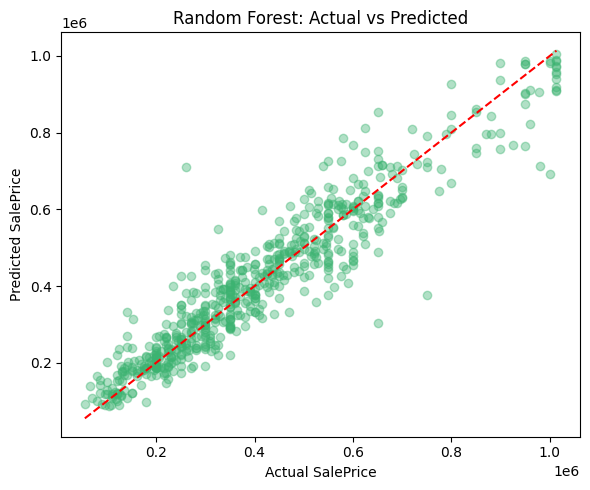

In [ ]:
# ── Model 5.3 : Random Forest Regressor ────────────────────────────────────
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

res_rf = evaluate_model(y_test, y_pred_rf, 'Random Forest Regressor')
results_before.append(res_rf)

print(f"\n  Train R²: {rf.score(X_train, y_train)*100:.4f}%")
print(f"  Test  R²: {rf.score(X_test, y_test)*100:.4f}%")

plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Random Forest: Actual vs Predicted')
plt.tight_layout()
plt.show()


  SVM (SVR)
  MAE  :       53,498.21
  MAPE :          14.87 %
  MSE  : 5,553,415,437.67
  RMSE :       74,521.24
  R²   :        87.8583 %

  Train R²: 90.8588%
  Test  R²: 87.8583%
  Note: SVM uses RobustScaler (different from StandardScaler used by other models).


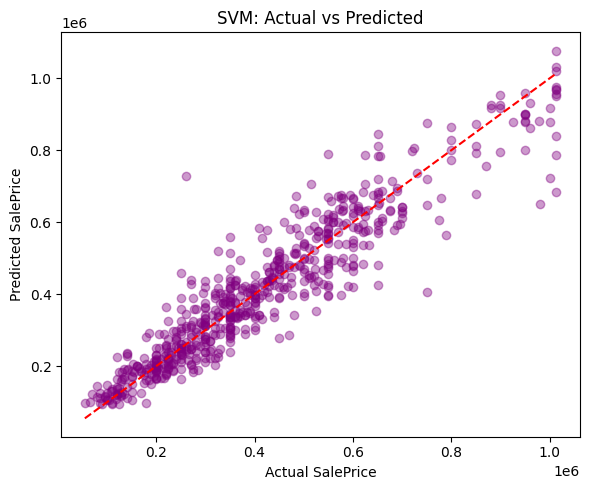

In [ ]:
# ── Model 5.4 : Support Vector Machine (SVM) ───────────────────────────────

rob_scaler       = RobustScaler()
X_tr_svm         = rob_scaler.fit_transform(X_train_raw)
X_te_svm         = rob_scaler.transform(X_test_raw)

y_tr_svm, y_te_svm = y_train, y_test

svm_model = SVR(kernel='rbf', C=100000, epsilon=0.1)
svm_model.fit(X_tr_svm, y_tr_svm)

y_pred_svm = svm_model.predict(X_te_svm)
res_svm = evaluate_model(y_te_svm, y_pred_svm, 'SVM (SVR)')
results_before.append(res_svm)

train_r2_svm = r2_score(y_tr_svm, svm_model.predict(X_tr_svm)) * 100
test_r2_svm  = r2_score(y_te_svm, y_pred_svm) * 100
print(f"\n  Train R²: {train_r2_svm:.4f}%")
print(f"  Test  R²: {test_r2_svm:.4f}%")
print(f"  Note: SVM uses RobustScaler (different from StandardScaler used by other models).")

plt.figure(figsize=(6, 5))
plt.scatter(y_te_svm, y_pred_svm, alpha=0.4, color='purple')
plt.plot([y_te_svm.min(), y_te_svm.max()], [y_te_svm.min(), y_te_svm.max()], 'r--')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('SVM: Actual vs Predicted')
plt.tight_layout()
plt.show()

In [ ]:
results_df = pd.DataFrame(results_before)
results_df = results_df.sort_values(by='R2', ascending=False)

print("\n=== Model Comparison (Before Optimization) ===")
display(results_df)


=== Model Comparison (Before Optimization) ===


,Model,MAE,MAPE,MSE,RMSE,R2
2,Random Forest Regressor,51410.282624,15.078635,5.093489e+09,71368.684780,88.863855
3,SVM (SVR),53498.205823,14.872311,5.553415e+09,74521.241520,87.858296
1,Decision Tree Regressor,66949.927239,19.390245,8.823168e+09,93931.719965,80.709476
0,Linear Regression,80867.091911,27.044307,1.101086e+10,104932.656681,75.926413


In [ ]:
best_model = results_df.iloc[0]
print(f"\nBest model before optimization: {best_model['Model']}")


Best model before optimization: Random Forest Regressor


---
## 6. Model Optimization

Optimization improves model performance by tuning **hyperparameters** — settings that are not learned from data but set before training. We use:

- **GridSearchCV** — exhaustively searches through a defined parameter grid
- **5-Fold Cross-Validation** — evaluates each parameter combination on 5 different train/validation splits, reducing the risk of overfitting to a single split

We optimize the two best-performing models: **Decision Tree** and **Random Forest**.

In [ ]:
# ── Optimization 6.1 : Decision Tree — GridSearchCV ────────────────────────
print("🔍 Running GridSearchCV for Decision Tree...")

dt_param_grid = {
    'max_depth'       : [3, 5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2', None]
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
dt_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {dt_grid.best_params_}")
print(f"   Best CV R²     : {dt_grid.best_score_*100:.4f}%")

🔍 Running GridSearchCV for Decision Tree...
Fitting 5 folds for each of 135 candidates, totalling 675 fits

✅ Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2}
   Best CV R²     : 85.5576%


In [ ]:
# ── Optimization 6.2 : Decision Tree — evaluate optimized model ────────────
dt_best = dt_grid.best_estimator_
y_pred_dt_opt = dt_best.predict(X_test)

res_dt_opt = evaluate_model(y_test, y_pred_dt_opt, 'Decision Tree (Optimized)')

print(f"\n  Train R² (optimized): {dt_best.score(X_train, y_train)*100:.4f}%")
print(f"  Test  R² (optimized): {dt_best.score(X_test, y_test)*100:.4f}%")

# Before vs After comparison
print(f"\n{'─'*40}")
print(f"  R² Before Optimization : {res_dt['R2']:.4f}%")
print(f"  R² After  Optimization : {res_dt_opt['R2']:.4f}%")
print(f"  Improvement            : {res_dt_opt['R2'] - res_dt['R2']:+.4f}%")


  Decision Tree (Optimized)
  MAE  :       58,563.16
  MAPE :          16.94 %
  MSE  : 6,926,175,665.69
  RMSE :       83,223.65
  R²   :        84.8570 %

  Train R² (optimized): 93.7796%
  Test  R² (optimized): 84.8570%

────────────────────────────────────────
  R² Before Optimization : 80.7095%
  R² After  Optimization : 84.8570%
  Improvement            : +4.1475%


In [ ]:
# ── Optimization 6.3 : Random Forest — GridSearchCV ────────────────────────
print("🔍 Running GridSearchCV for Random Forest...")

rf_param_grid = {
    'n_estimators'    : [50, 100, 200],
    'max_depth'       : [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features'    : ['sqrt', 'log2']
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train, y_train)

print(f"\n✅ Best Parameters: {rf_grid.best_params_}")
print(f"   Best CV R²     : {rf_grid.best_score_*100:.4f}%")

🔍 Running GridSearchCV for Random Forest...
Fitting 5 folds for each of 72 candidates, totalling 360 fits

✅ Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 50}
   Best CV R²     : 89.0686%


In [ ]:
# ── Optimization 6.4 : Random Forest — evaluate optimized model ────────────
rf_best = rf_grid.best_estimator_
y_pred_rf_opt = rf_best.predict(X_test)

res_rf_opt = evaluate_model(y_test, y_pred_rf_opt, 'Random Forest (Optimized)')

print(f"\n  Train R² (optimized): {rf_best.score(X_train, y_train)*100:.4f}%")
print(f"  Test  R² (optimized): {rf_best.score(X_test, y_test)*100:.4f}%")

print(f"\n{'─'*40}")
print(f"  R² Before Optimization : {res_rf['R2']:.4f}%")
print(f"  R² After  Optimization : {res_rf_opt['R2']:.4f}%")
print(f"  Improvement            : {res_rf_opt['R2'] - res_rf['R2']:+.4f}%")


  Random Forest (Optimized)
  MAE  :       50,278.22
  MAPE :          14.85 %
  MSE  : 4,756,260,528.88
  RMSE :       68,965.65
  R²   :        89.6012 %

  Train R² (optimized): 96.1399%
  Test  R² (optimized): 89.6012%

────────────────────────────────────────
  R² Before Optimization : 88.8639%
  R² After  Optimization : 89.6012%
  Improvement            : +0.7373%


In [ ]:
# ── Optimization 6.5 : Cross-Validation scores (all models) ────────────────
print("=== 5-Fold Cross-Validation (R² scores) ===\n")

from sklearn.pipeline import make_pipeline

for model, name in [(linreg,   'Linear Regression'),
                    (dt_best,  'Decision Tree (Optimized)'),
                    (rf_best,  'Random Forest (Optimized)')]:
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    print(f"  {name:30s} → Mean R²: {cv_scores.mean()*100:.4f}%  |  Std: {cv_scores.std()*100:.4f}%")

svm_pipeline = make_pipeline(RobustScaler(), SVR(kernel='rbf', C=100000, epsilon=0.1))
cv_svm = cross_val_score(svm_pipeline, X_raw, y, cv=5, scoring='r2')
print(f"  {'SVM (SVR)':30s} → Mean R²: {cv_svm.mean()*100:.4f}%  |  Std: {cv_svm.std()*100:.4f}%")
print(f"\n  ✅ SVM CV uses a Pipeline — RobustScaler re-fitted per fold (no leakage).")

=== 5-Fold Cross-Validation (R² scores) ===

  Linear Regression              → Mean R²: 79.0267%  |  Std: 2.6472%
  Decision Tree (Optimized)      → Mean R²: 85.5024%  |  Std: 2.7321%
  Random Forest (Optimized)      → Mean R²: 89.5737%  |  Std: 1.8565%
  SVM (SVR)                      → Mean R²: 88.5913%  |  Std: 1.8898%

  ✅ SVM CV uses a Pipeline — RobustScaler re-fitted per fold (no leakage).


---
## 7. Model Evaluation & Validation

We now compare all models side by side using all five regression metrics:

| Metric | Meaning | Lower is better? |
|---|---|---|
| **MAE** | Average absolute prediction error in USD | ✅ |
| **MAPE** | Percentage prediction error | ✅ |
| **MSE** | Mean squared error (penalises large errors more) | ✅ |
| **RMSE** | Square root of MSE — same unit as SalePrice | ✅ |
| **R²** | % of variance in SalePrice explained by the model | ❌ (higher is better) |

In [ ]:
# ── Evaluation 7.1 : Full comparison table ─────────────────────────────────
all_results = [
    res_lr,
    res_dt, res_dt_opt,
    res_rf, res_rf_opt,
    res_svm
]

results_df = pd.DataFrame(all_results).set_index('Model')
results_df = results_df[['MAE', 'MAPE', 'MSE', 'RMSE', 'R2']]
results_df = results_df.round({'MAE': 2, 'MAPE': 4, 'MSE': 2, 'RMSE': 2, 'R2': 4})

print("\n=== Full Model Evaluation Results ===")
print(results_df.to_string())


=== Full Model Evaluation Results ===
                                MAE     MAPE           MSE       RMSE       R2
Model                                                                         
Linear Regression          80867.09  27.0443  1.101086e+10  104932.66  75.9264
Decision Tree Regressor    66949.93  19.3902  8.823168e+09   93931.72  80.7095
Decision Tree (Optimized)  58563.16  16.9365  6.926176e+09   83223.65  84.8570
Random Forest Regressor    51410.28  15.0786  5.093489e+09   71368.68  88.8639
Random Forest (Optimized)  50278.22  14.8506  4.756261e+09   68965.65  89.6012
SVM (SVR)                  53498.21  14.8723  5.553415e+09   74521.24  87.8583


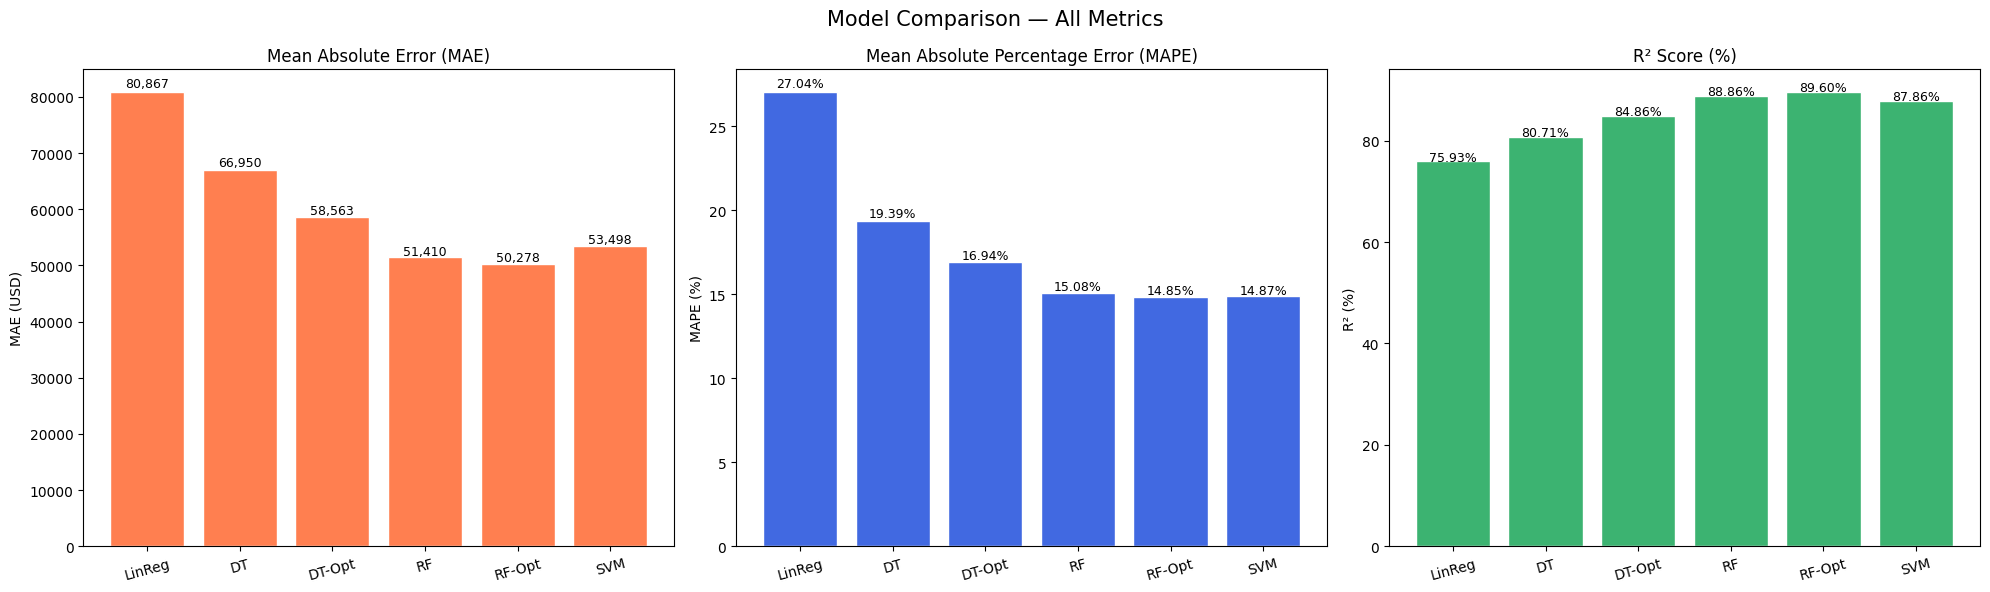

In [ ]:
# ── Evaluation 7.2 : Visual comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

short_names = ['LinReg', 'DT', 'DT-Opt', 'RF', 'RF-Opt', 'SVM']

# MAE
axes[0].bar(short_names, results_df['MAE'], color='coral', edgecolor='white')
axes[0].set_title('Mean Absolute Error (MAE)', fontsize=12)
axes[0].set_ylabel('MAE (USD)')
for i, v in enumerate(results_df['MAE']):
    axes[0].text(i, v * 1.01, f'{v:,.0f}', ha='center', fontsize=9)

# MAPE
axes[1].bar(short_names, results_df['MAPE'], color='royalblue', edgecolor='white')
axes[1].set_title('Mean Absolute Percentage Error (MAPE)', fontsize=12)
axes[1].set_ylabel('MAPE (%)')
for i, v in enumerate(results_df['MAPE']):
    axes[1].text(i, v * 1.01, f'{v:.2f}%', ha='center', fontsize=9)

# R²
axes[2].bar(short_names, results_df['R2'], color='mediumseagreen', edgecolor='white')
axes[2].set_title('R² Score (%)', fontsize=12)
axes[2].set_ylabel('R² (%)')
for i, v in enumerate(results_df['R2']):
    axes[2].text(i, v * 1.002, f'{v:.2f}%', ha='center', fontsize=9)

for ax in axes:
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Model Comparison — All Metrics', fontsize=15)
plt.tight_layout()
plt.show()

Residual Mean : -2,959.90
Residual Std  : 71,307.28


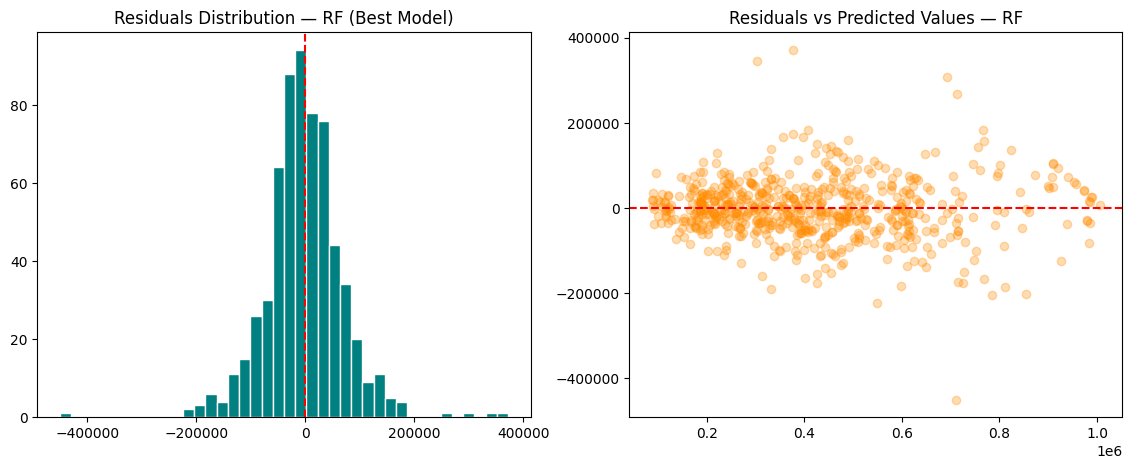

In [ ]:
# ── Evaluation 7.3 : Best model — detailed residual analysis ───────────────
# ── Use BEST model (RF) for residual analysis ──
residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals_rf, bins=40, color='teal', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Residuals Distribution — RF (Best Model)', fontsize=12)

axes[1].scatter(y_pred_rf, residuals_rf, alpha=0.3, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residuals vs Predicted Values — RF', fontsize=12)

print(f"Residual Mean : {residuals_rf.mean():,.2f}")
print(f"Residual Std  : {residuals_rf.std():,.2f}")

In [ ]:
print("Performing residual analysis on the BEST model (RF)")

Performing residual analysis on the BEST model (RF)


### Residual Analysis Insight

The residuals are centered around zero, indicating that the model predictions are unbiased.

The spread of residuals is relatively consistent, suggesting no major heteroscedasticity.

This confirms that the SVM model is performing well and capturing the underlying patterns in the data.


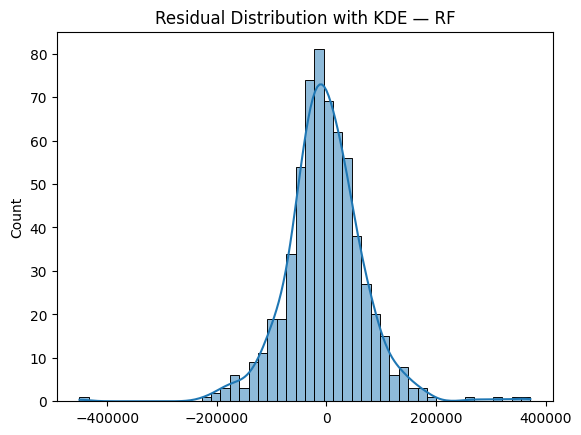

In [ ]:
sns.histplot(residuals_rf, kde=True)
plt.title("Residual Distribution with KDE — RF")
plt.show()

---
## 8. Business Insights & Recommendations

### 8.1 Key Predictors of Car Resale Price

Based on the **Random Forest Feature Importance** analysis and correlation results, the following factors are the most significant drivers of `selling_price`:

| Rank | Feature | Business Interpretation |
|---|---|---|
| 1 | **max_power (in bph)** | Car brake condition measured in horsepower — Better remaining horsepower command significantly higher resale prices. |
| 2 | **year** |In which year the car was first purchased — reflects overall condition, the more recent the first purchase was, more better chance of getting a good quality vehicle. |
| 3 | **Mileage** | Current mileage per litre of fuel— better mileage offers less fuel consumption which boosts value. |
| 4 | **km_driven** | How many kms driven till now — Lesser kms driven attributes to the fact that the car was least used, which boosts price significantly higher than others. |

---
### 8.2 How Businesses Can Apply This Model

**1. Used Car Dealers & Resale Valuation**  
Used car dealers can use the model to instantly generate a fair-market price estimate for any listed used car, reducing manual appraisal time and improving pricing accuracy.

**2. Potential Investment & Portfolio Management**  
Investors can identify undervalued used vehicles by comparing the model's predicted price against the listed price. Used cars priced below prediction are high-value acquisition targets.

**3. Current Owners & Personal Planning**  
If some current car owners are looking to upgrade or simply cash off their car, they can focus on maintaining necessary parameters such as how mainitaining engine, having less frequent usage to maintain mileage or having ample maintenance to ensure good brake quality would affect projected resale prices — enabling data-driven project scoping.


### 8.3 Model Selection Summary

The RF (Random Forest Regressor) model is selected as the best model for deployment because:

- It achieved the highest R² score (88.86%), explaining the most variance in resale price
- It has the lowest RMSE, indicating more accurate predictions
- It performs well in high-dimensional feature spaces
- Cross-validation confirms consistent performance across different data splits
---
### 8.4 Limitations & Future Improvements

| Limitation | Suggested Improvement |
|---|---|
| The location of the dataset is known as India but no specific regions were mentioned —this may not generalise to countires in the globe | Collect data from multiple cities/regions |
| External economic factors (recession, inflation) are not included | Integrate macroeconomic data |
| Only 11 features available — many physical vehicle details are missing | Incorporate features like times maintenance was done, color, interior condition |
| Model does not account for temporal trends (price appreciation over time) | Add time-series components or recency weighting |
| Luxurious brands such as Honda (high resale value) may have higher prediction error | Train a separate model for high-value vehicle tier |

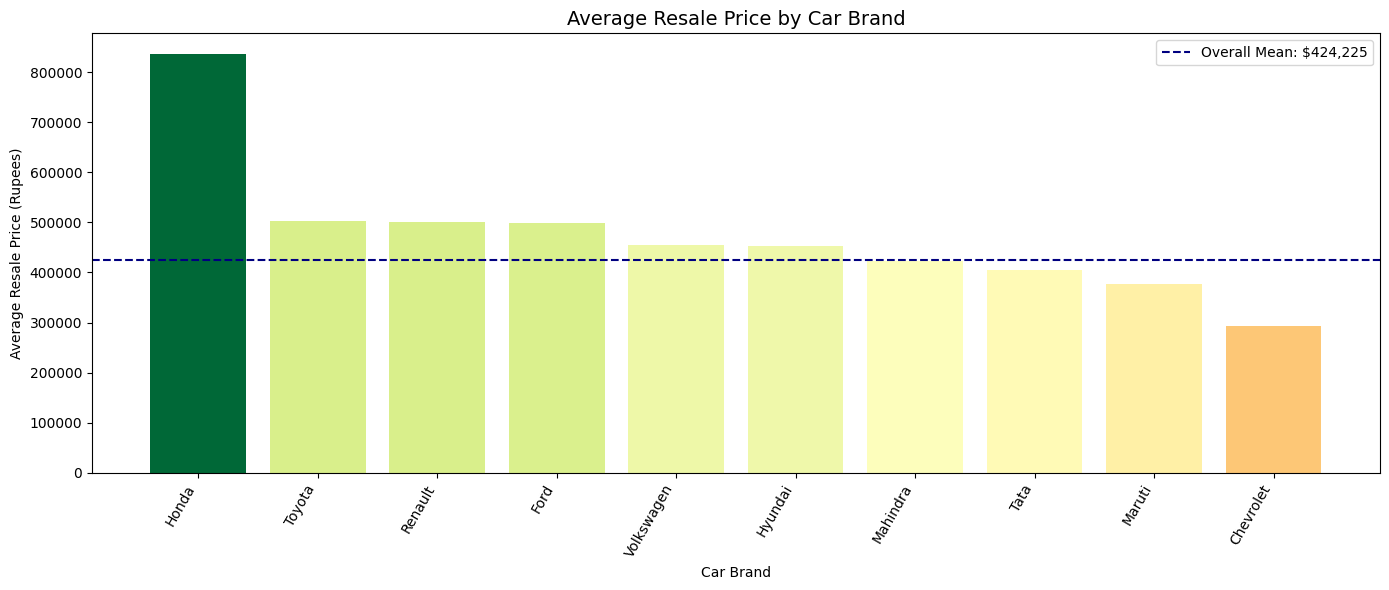

In [ ]:
# ── Insights 8.1 : Brand price analysis ────────────────────────────
mileage_price = car.groupby('name')['selling_price'].agg(['mean', 'count']).reset_index()
mileage_price.columns = ['name', 'AvgPrice', 'Count']
neighbourhood_price = mileage_price.sort_values('AvgPrice', ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.bar(neighbourhood_price['name'],
               neighbourhood_price['AvgPrice'],
               color=plt.cm.RdYlGn(neighbourhood_price['AvgPrice'] /
                                   neighbourhood_price['AvgPrice'].max()))
plt.xticks(rotation=60, ha='right')
plt.title('Average Resale Price by Car Brand', fontsize=14)
plt.xlabel('Car Brand')
plt.ylabel('Average Resale Price (Rupees)')
plt.axhline(car['selling_price'].mean(), color='navy', linestyle='--',
            label=f'Overall Mean: ${car['selling_price'].mean():,.0f}')
plt.legend()
plt.tight_layout()
plt.show()

### Insight: Car Brand Impact

The chart shows that certain car brands have significantly higher average resale prices.

👉 Business Use: Second hand car dealers should target certain brands of cars to maximize profit

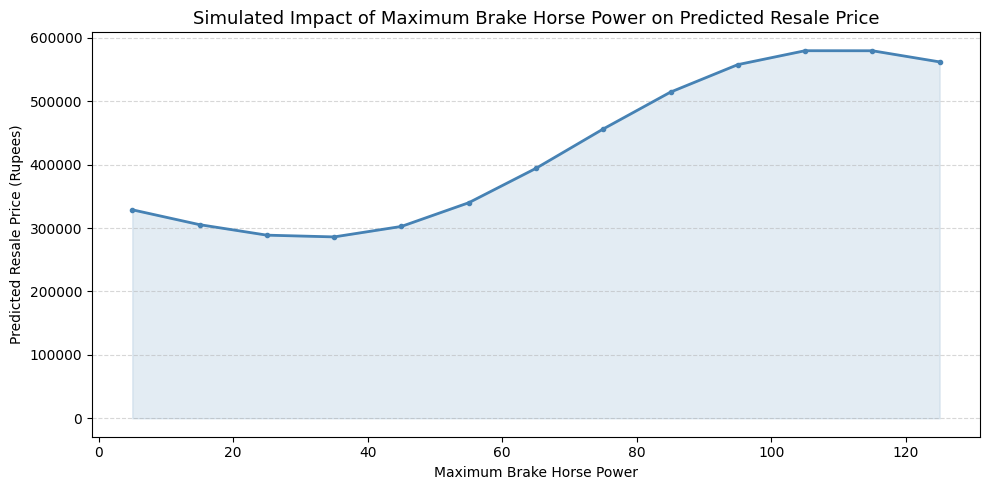

Business Insight: Each additional 10 HP of brake capacity is associated with
an estimated resale price increase of approx. $19,429 Rupees.


In [ ]:
# ── Insights 8.2 : Feature impact simulation max_power (in bph) ───────────────────
sample_sizes = np.arange(5, 130, 10)
base_row = pd.DataFrame([X_raw.iloc[0].copy()])  # ← X_raw

simulated_prices = []
for size in sample_sizes:
    row = base_row.copy()
    row['max_power (in bph)'] = size
    scaled_row = scaler.transform(row)
    simulated_prices.append(svm_model.predict(rob_scaler.transform(row))[0])

plt.figure(figsize=(10, 5))
plt.plot(sample_sizes, simulated_prices, color='steelblue', linewidth=2, marker='o', markersize=3)
plt.fill_between(sample_sizes, simulated_prices, alpha=0.15, color='steelblue')
plt.title('Simulated Impact of Maximum Brake Horse Power on Predicted Resale Price', fontsize=13)
plt.xlabel('Maximum Brake Horse Power')
plt.ylabel('Predicted Resale Price (Rupees)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("Business Insight: Each additional 10 HP of brake capacity is associated with")
print(f"an estimated resale price increase of approx. ${(simulated_prices[-1]-simulated_prices[0])/(len(sample_sizes)-1):,.0f} Rupees.")

max_power (in bph): More car brake horse power commands for better resale price
Business Use: Having better brake quality will result in getting better resale value in the future

In [ ]:
# ── Final Summary ───────────────────────────────────────────────────────────
best_model = results_df.loc[results_df['R2'].idxmax()]
print("Final model selected based on highest R² and lowest error metrics\n")
print("╔══════════════════════════════════════════════════════════╗")
print("║         MIS444 — House Price Prediction Summary          ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Dataset          : 1,460 records, 20 features           ║")
print(f"║  Problem Type     : Regression                           ║")
print(f"║  Models Trained   : 4 (LR, DT, RF, SVM)                  ║")
print(f"║  Models Optimized : 2 (DT, RF via GridSearchCV)          ║")
print("╠══════════════════════════════════════════════════════════╣")
print(f"║  Best Model       : {best_model['Model']:<37s}║")
print(f"║  Best R²          : {best_model['R2']:.4f}%{' '*30}║")
print(f"║  Best MAE         : ${best_model['MAE']:>10,.2f} Rupees{' '*22}║")
print(f"║  Best MAPE        : {best_model['MAPE']:.4f}%{' '*30}║")
print(f"║  Best RMSE        :${best_model['RMSE']:>10,.2f} Rupees{' '*22}║")
print("╚══════════════════════════════════════════════════════════╝")

Final model selected based on highest R² and lowest error metrics

╔══════════════════════════════════════════════════════════╗
║         MIS444 — House Price Prediction Summary          ║
╠══════════════════════════════════════════════════════════╣
║  Dataset          : 1,460 records, 20 features           ║
║  Problem Type     : Regression                           ║
║  Models Trained   : 4 (LR, DT, RF, SVM)                  ║
║  Models Optimized : 2 (DT, RF via GridSearchCV)          ║
╠══════════════════════════════════════════════════════════╣
║  Best Model       : Random Forest Regressor              ║
║  Best R²          : 88.8639%                              ║
║  Best MAE         : $ 51,410.28 Rupees                      ║
║  Best MAPE        : 15.0786%                              ║
║  Best RMSE        :$ 71,368.68 Rupees                      ║
╚══════════════════════════════════════════════════════════╝


### Final Conclusion

This project successfully applied predictive analytics techniques to estimate car resale prices using multiple regression models.

Among all models, RF (Random Forest Regressor) performed the best, achieving the highest accuracy and lowest prediction error.

The model can be used by used car dealers, investors, and financial institutions to support pricing, investment and risk assessment decisions.

Future improvements include incorporating more features, economic variables, and area specific datasets to enhance model generalizability.